## ЗВІТ 


In [2]:
import pandas as pd

   # Завантаження даних
df = pd.read_csv('StudentPerformanceFactors.csv')

   # Перегляд перших рядків
print(df.head())
   
   # Огляд інформації про набір даних
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [1]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('StudentPerformanceFactors.csv')

# Перевірка на пропущені значення
print("Пропущені значення:")
print(df.isnull().sum())

# Заповнення пропущених значень у числових стовпцях середнім
numeric_columns = df.select_dtypes(include='number').columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

# Заповнення пропущених значень у категоріальних стовпцях модою
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Видалення дублікатів
df.drop_duplicates(inplace=True)

# Перетворення категоріальних змінних на числові
for column in categorical_columns:
    df[column] = df[column].astype('category').cat.codes

# Перевірка результату
print("\nТипи даних після обробки:")
print(df.dtypes)

Пропущені значення:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Типи даних після обробки:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement           int8
Access_to_Resources            int8
Extracurricular_Activities     int8
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level            

C:\Users\vladk\AppData\Local\Temp\ipykernel_19072\2967355917.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [2]:
# Описова статистика
print(df.describe())

       Hours_Studied   Attendance  Parental_Involvement  Access_to_Resources  \
count    6607.000000  6607.000000           6607.000000          6607.000000   
mean       19.975329    79.977448              1.220070             1.203421   
std         5.990594    11.547475              0.865634             0.871783   
min         1.000000    60.000000              0.000000             0.000000   
25%        16.000000    70.000000              0.000000             0.000000   
50%        20.000000    80.000000              2.000000             2.000000   
75%        24.000000    90.000000              2.000000             2.000000   
max        44.000000   100.000000              2.000000             2.000000   

       Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
count                 6607.000000   6607.00000      6607.000000   
mean                     0.596035      7.02906        75.070531   
std                      0.490728      1.46812        14.399784   
min        

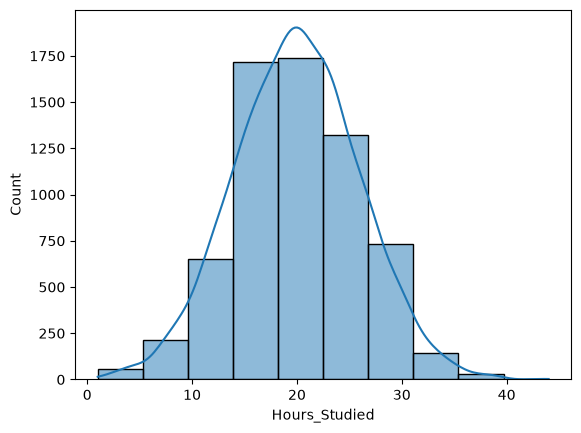

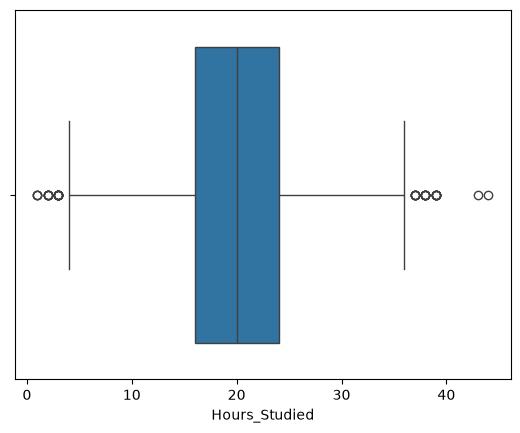

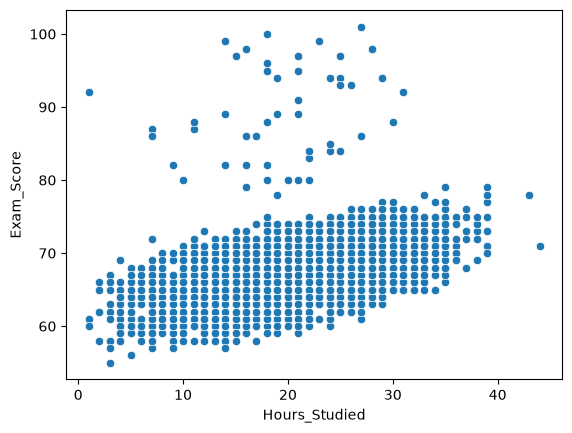

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Гістограма для кількісної змінної
sns.histplot(df['Hours_Studied'], bins=10, kde=True)
plt.show()

# Коробкова діаграма для аналізу викидів
sns.boxplot(x=df['Hours_Studied'])
plt.show()

# Діаграма розсіювання для двох кількісних змінних
sns.scatterplot(
    x=df['Hours_Studied'],
    y=df['Exam_Score']
)
plt.show()

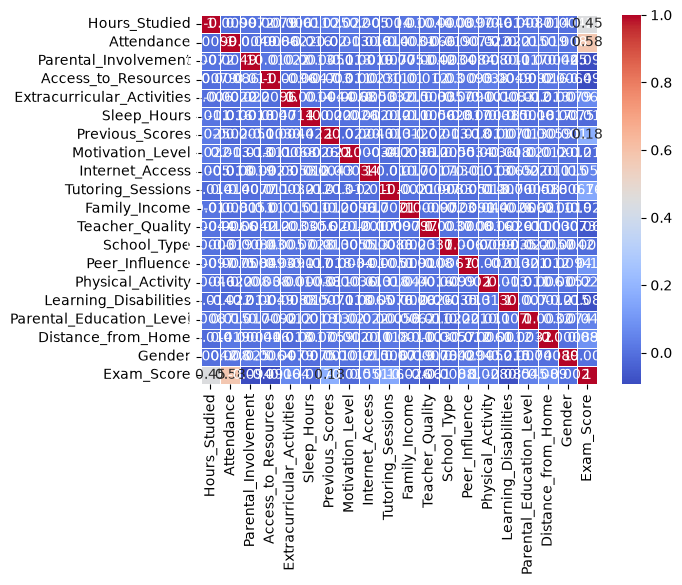

In [6]:
# Кореляційна матриця
correlation_matrix = df.corr()

   # Візуалізація кореляційної матриці
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()